## Financial Risk Analysis with Python

### Task 1: Data Cleaning and Formatting

In [2]:
import pandas as pd
import numpy as np

In [3]:
ms_df=pd.read_csv(r"C:\Users\shash\OneDrive\Documents\Kala\Python\morgan_stanely.csv")

In [4]:
ms_df.dtypes

TransactionID          int64
CustomerID            object
AccountID             object
AccountType           object
TransactionType       object
Product               object
Firm                  object
Region                object
Manager               object
TransactionDate       object
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

In [5]:
ms_df['AccountID'].nunique()

189

In [6]:
ms_df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [7]:
ms_df['TransactionDate'] = pd.to_datetime(ms_df['TransactionDate'], format='%d-%m-%Y')
ms_df['TransactionType'] = ms_df['TransactionType'].str.lower().str.strip()
ms_df['Year'] = ms_df['TransactionDate'].dt.year
ms_df['Month'] = ms_df['TransactionDate'].dt.to_period('M')

In [8]:
ms_df.dtypes

TransactionID                 int64
CustomerID                   object
AccountID                    object
AccountType                  object
TransactionType              object
Product                      object
Firm                         object
Region                       object
Manager                      object
TransactionDate      datetime64[ns]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                  int64
TenureMonths                  int64
Year                          int32
Month                     period[M]
dtype: object

In [9]:
ms_df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
0,78,CUST1223,ACC33287,Credit,withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13,2023,2023-01
1,21,CUST8266,ACC58667,Savings,withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18,2023,2023-02
2,176,CUST9420,ACC99117,Credit,transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25,2023,2023-09
3,167,CUST5253,ACC10117,Loan,payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13,2024,2024-05
4,46,CUST1223,ACC74631,Savings,deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10,2023,2023-05


In [10]:
ms_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
795    False
796    False
797    False
798    False
799    False
Length: 800, dtype: bool

In [11]:
ms_df["TransactionAmount"]=ms_df["TransactionAmount"].abs()
ms_df["TransactionAmount"].min()

458.4849094

In [12]:
ms_df.isna().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
Year                 0
Month                0
dtype: int64

### Task 2: Descriptive Transactional Analysis

##### 2.1 Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [13]:
ms_df['Credit'] = ms_df['TransactionAmount'].where(ms_df['TransactionType'] == 'deposit', 0)
ms_df['Debit'] = ms_df['TransactionAmount'].where(
    ms_df['TransactionType'].isin([ 'withdrawal', 'transfer', 'payment']), 0
)

# Monthly summary
monthly_summary = (
    ms_df.groupby("Month")[['Credit', 'Debit']]
      .sum()
      .assign(Net_Transaction_Volume=lambda x: x.Credit - x.Debit)
      .reset_index()
)

# Yearly summary
yearly_summary = (
    ms_df.groupby('Year')[['Credit', 'Debit']]
      .sum()
      .assign(Net_Transaction_Volume=lambda x: x.Credit - x.Debit)
      .reset_index()
)
print("Monthly Summary")
print(monthly_summary)
print("\nYearly Summary")
print(yearly_summary)


Monthly Summary
      Month         Credit         Debit  Net_Transaction_Volume
0   2023-01  739627.612080  2.151576e+06           -1.411949e+06
1   2023-02  790624.996440  1.707597e+06           -9.169718e+05
2   2023-03  428688.199330  1.686808e+06           -1.258120e+06
3   2023-04  652566.551828  2.442296e+06           -1.789730e+06
4   2023-05  467715.546470  2.454034e+06           -1.986319e+06
5   2023-06  537122.475023  1.022615e+06           -4.854928e+05
6   2023-07  776072.726920  1.706737e+06           -9.306644e+05
7   2023-08  473701.358178  1.355915e+06           -8.822140e+05
8   2023-09  863982.068180  1.884473e+06           -1.020491e+06
9   2023-10  954771.219221  2.606035e+06           -1.651263e+06
10  2023-11  529279.878250  2.808723e+06           -2.279443e+06
11  2023-12  540703.001784  1.573679e+06           -1.032976e+06
12  2024-01  582366.947600  1.246298e+06           -6.639307e+05
13  2024-02  464351.732358  2.352828e+06           -1.888477e+06
14  2024-

##### 2.2 Plot trends in total credits vs. debits over time.

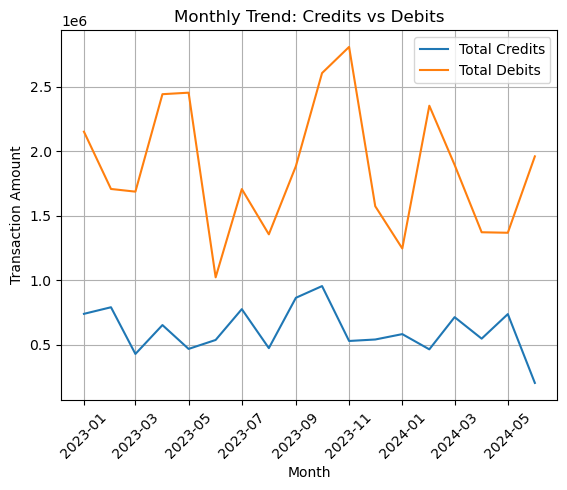

In [14]:
import matplotlib.pyplot as plt
monthly_summary['Month'] = monthly_summary['Month'].dt.to_timestamp()
plt.figure()
plt.xticks(rotation=45)
plt.plot(monthly_summary['Month'], monthly_summary['Credit'], label='Total Credits')
plt.plot(monthly_summary['Month'], monthly_summary['Debit'], label='Total Debits')
plt.xlabel('Month')
plt.ylabel('Transaction Amount')
plt.title('Monthly Trend: Credits vs Debits')
plt.legend()
plt.grid()
plt.show()

##### 2.3 Identify top and bottom performing accounts based on net inflow.

In [15]:
account_summary1 = (
    ms_df.groupby('AccountID')[['Credit', 'Debit']]
      .sum()
      .assign(Net_Inflow=lambda x: x.Credit - x.Debit)
      .reset_index()
)

# Top 5 and Bottom 5 accounts
top_accounts = account_summary1.sort_values('Net_Inflow', ascending=False).head(5)
bottom_accounts = account_summary1.sort_values('Net_Inflow').head(5)

print("Top Performing Accounts")
print(top_accounts)

print("\nBottom Performing Accounts")
print(bottom_accounts)

Top Performing Accounts
    AccountID         Credit         Debit     Net_Inflow
69   ACC38559  219919.516230  44067.307744  175852.208486
112  ACC57700  250121.858500  78718.715500  171403.143000
55   ACC31539  150937.249760  21990.050000  128947.199760
102  ACC51971  115097.311765      0.000000  115097.311765
18   ACC18177  174360.269780  71865.548810  102494.720970

Bottom Performing Accounts
    AccountID       Credit         Debit    Net_Inflow
118  ACC61926  60238.27980  753412.31995 -693174.04015
0    ACC10117  52336.34278  583998.70786 -531662.36508
99   ACC51009  39011.23849  532634.18963 -493622.95114
169  ACC88449  66198.87121  524857.86232 -458658.99111
20   ACC19178  62859.62790  491586.39945 -428726.77155


##### 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [20]:
ms_df = ms_df.sort_values(['AccountID', 'TransactionDate'])
ms_df['Gap_Days'] = (ms_df.groupby('AccountID')['TransactionDate'].diff().dt.days)
account_gap1 = (ms_df.groupby('AccountID')['Gap_Days'].max().reset_index())
account_gap1['Account_Status'] = account_gap1['Gap_Days'].apply(
    lambda x: 'Dormant' if x > 60 else 'Active')
account_gap1
ms_df = ms_df.merge(
    account_gap1[['AccountID', 'Account_Status']],
    on='AccountID',
    how='left'
)

ms_df


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,Credit,Debit,Gap_Days,Account_Status
0,72,CUST1498,ACC10117,Current,deposit,Mutual Fund,Firm D,North,Manager 1,2023-01-30,...,46657.21790,0.227450,659,16,2023,2023-01,52336.34278,0.00000,NaN,Dormant
1,173,CUST2067,ACC10117,Current,transfer,Personal Loan,Firm D,East,Manager 1,2023-04-30,...,180539.28770,0.396153,393,45,2023,2023-04,0.00000,77018.97098,90.0,Dormant
2,127,CUST9528,ACC10117,Savings,transfer,Mutual Fund,Firm C,East,Manager 4,2023-06-20,...,80204.67302,0.457247,618,181,2023,2023-06,0.00000,65805.20213,51.0,Dormant
3,180,CUST2541,ACC10117,Current,withdrawal,Credit Card,Firm A,Central,Manager 4,2023-07-14,...,70489.10944,0.185195,494,223,2023,2023-07,0.00000,89395.76266,24.0,Dormant
4,114,CUST8091,ACC10117,Savings,withdrawal,Credit Card,Firm A,South,Manager 3,2023-08-04,...,99972.73002,-0.010665,619,225,2023,2023-08,0.00000,18353.15647,21.0,Dormant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,50,CUST4625,ACC99549,Credit,transfer,Personal Loan,Firm E,North,Manager 3,2023-06-06,...,105166.59750,0.486469,360,50,2023,2023-06,0.00000,72499.16252,33.0,Dormant
796,124,CUST7855,ACC99549,Current,transfer,Credit Card,Firm D,West,Manager 1,2023-07-19,...,110405.27400,0.686125,529,83,2023,2023-07,0.00000,82091.03853,43.0,Dormant
797,142,CUST4461,ACC99549,Credit,deposit,Savings Account,Firm A,North,Manager 2,2024-02-04,...,110685.58450,0.644535,715,174,2024,2024-02,77101.58761,0.00000,200.0,Dormant
798,136,CUST4669,ACC99549,Current,transfer,Credit Card,Firm B,Central,Manager 3,2024-02-21,...,70920.37000,0.296737,589,9,2024,2024-02,0.00000,97870.57220,17.0,Dormant


### Task 3: Customer Profile Building

##### 3.1 Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

* If transaction count <=4 activity level is "low", less than 9 "Medium" else it is "High"

In [21]:
account_txn_count = (
    ms_df.groupby('AccountID')
         .size()
         .reset_index(name='Transaction_Count')
)
def classify_activity(x):
    if x <= 4:
        return 'Low volume'
    elif x < 9:
        return 'Medium volume'
    else:
        return 'High volume'
account_txn_count['Activity_Level'] = account_txn_count['Transaction_Count'].apply(classify_activity)
print(account_txn_count)

    AccountID  Transaction_Count Activity_Level
0    ACC10117                  9    High volume
1    ACC10996                  8  Medium volume
2    ACC11062                  4     Low volume
3    ACC11188                  2     Low volume
4    ACC11285                  5  Medium volume
..        ...                ...            ...
184  ACC96868                  5  Medium volume
185  ACC97411                  4     Low volume
186  ACC99117                  2     Low volume
187  ACC99409                  2     Low volume
188  ACC99549                  9    High volume

[189 rows x 3 columns]


##### 3.2 Segment customers by average balance and transaction volume.

In [29]:
avg_balance=ms_df.groupby("AccountID")["AccountBalance"].mean().reset_index()
avg_balance.rename(columns={"AccountBalance":"AvgBalance"}, inplace=True)
cus_segment=pd.merge(avg_balance,account_txn_count,on="AccountID")
cus_segment.head()

,AccountID,AvgBalance,Transaction_Count,Activity_Level
0,ACC10117,94082.590727,9,High volume
1,ACC10996,72517.761136,8,Medium volume
2,ACC11062,73541.328302,4,Low volume
3,ACC11188,51359.039950,2,Low volume
4,ACC11285,79923.619870,5,Medium volume


In [30]:
avg_balance.max()

AccountID         ACC99549
AvgBalance    117133.77655
dtype: object

Rubrics:If balance >80000 High balance,>=30000 Medium balance,otherwise low balance.
transaction count >=9 High volume,>4 Medium volume otherwise low volume

In [31]:
def balance_category(x):
    if x>80000:
        return "High balance"
    elif x>=30000:
        return "Medium balance"
    else:
        return "Low balance"
cus_segment["BalanceCategory"]=cus_segment["AvgBalance"].apply(balance_category)

cus_segment

,AccountID,AvgBalance,Transaction_Count,Activity_Level,BalanceCategory
0,ACC10117,94082.590727,9,High volume,High balance
1,ACC10996,72517.761136,8,Medium volume,Medium balance
2,ACC11062,73541.328302,4,Low volume,Medium balance
3,ACC11188,51359.039950,2,Low volume,Medium balance
4,ACC11285,79923.619870,5,Medium volume,Medium balance
...,...,...,...,...,...
184,ACC96868,73833.947050,5,Medium volume,Medium balance
185,ACC97411,32190.912745,4,Low volume,Medium balance
186,ACC99117,110239.787525,2,Low volume,High balance
187,ACC99409,33525.389300,2,Low volume,Medium balance


#### Task 3.3 Create profiles for:
○ High-net inflow accounts
○ High-frequency low-balance accounts
○ Accounts with negative or near-zero balances

In [32]:
def segment_account(row):
    
    # Rule 1: Low Balance + High Volume (more specific condition first)
    if row['Activity_Level'] == 'High volume' and row['BalanceCategory'] == 'Low balance':
        return "High-frequency low-balance account"
    
    # Rule 2: High Volume
    elif row['Activity_Level'] == 'High volume':
        return "High net inflow account"
    
    elif row['BalanceCategory'] == 'Low balance':
        return "Accounts with negative or near-zero balances"
    
    # Rule 4: Others
    else:
        return "Regular Account"

cus_segment['Customer_Segment'] = cus_segment.apply(segment_account, axis=1)
cus_segment

,AccountID,AvgBalance,Transaction_Count,Activity_Level,BalanceCategory,Customer_Segment
0,ACC10117,94082.590727,9,High volume,High balance,High net inflow account
1,ACC10996,72517.761136,8,Medium volume,Medium balance,Regular Account
2,ACC11062,73541.328302,4,Low volume,Medium balance,Regular Account
3,ACC11188,51359.039950,2,Low volume,Medium balance,Regular Account
4,ACC11285,79923.619870,5,Medium volume,Medium balance,Regular Account
...,...,...,...,...,...,...
184,ACC96868,73833.947050,5,Medium volume,Medium balance,Regular Account
185,ACC97411,32190.912745,4,Low volume,Medium balance,Regular Account
186,ACC99117,110239.787525,2,Low volume,High balance,Regular Account
187,ACC99409,33525.389300,2,Low volume,Medium balance,Regular Account


### Task 4: Financial Risk Identification

##### 4.1 Track accounts with frequent large withdrawals or overdrafts

In [ ]:
overdraft_accounts = ms_df[ms_df['AccountBalance'] < 0]['AccountID'].unique()
overdraft_accounts

In [26]:
debits = ms_df[ms_df["TransactionType"] == "Debit"]

large_withdrawal_threshold = debits["TransactionAmount"].quantile(0.75)
large_withdrawal_threshold

large_withdrawals = debits[debits["TransactionAmount"] >= large_withdrawal_threshold]

large_withdrawal_counts = large_withdrawals.groupby("AccountID")["TransactionID"].count().reset_index()
large_withdrawal_counts.columns = ["AccountID", "LargeWithdrawalCount"]

def risk_category(x):
    if x >= 5:
        return "High Risk"
    elif x >= 2:
        return "Medium Risk"
    else:
        return "Low Risk"

large_withdrawal_counts["RiskLevel"] = large_withdrawal_counts["LargeWithdrawalCount"].apply(risk_category)

print("\nAccounts with large Withdrawals:\n")
display(large_withdrawal_counts)



Accounts with large Withdrawals:



,AccountID,LargeWithdrawalCount,RiskLevel


##### 4.2 Calculate balance volatility using standard deviation or coefficient of variation.

In [24]:
balance_volatility = ms_df.groupby('AccountID')['AccountBalance'].std().reset_index(name='Balance_Volatility')
balance_volatility.head()
account_summary1 = account_summary1.merge(balance_volatility, 
                                        on='AccountID', 
                                        how='left')

vol_q75 = account_summary1['Balance_Volatility'].quantile(0.75)
vol_q25 = account_summary1['Balance_Volatility'].quantile(0.25)

def volatility_segment(x):
    if x >= vol_q75:
        return "High Volatility"
    elif x <= vol_q25:
        return "Low Volatility"
    else:
        return "Medium Volatility"

account_summary1['Volatility_Segment'] = account_summary1['Balance_Volatility'].apply(volatility_segment)
account_summary1


,AccountID,Credit,Debit,Net_Inflow,Balance_Volatility,Volatility_Segment
0,ACC10117,52336.34278,583998.707860,-531662.365080,38036.539989,Medium Volatility
1,ACC10996,254968.10439,251778.053670,3190.050720,30036.385595,Medium Volatility
2,ACC11062,0.00000,247384.209240,-247384.209240,33831.704345,Medium Volatility
3,ACC11188,0.00000,127634.925880,-127634.925880,9067.866694,Low Volatility
4,ACC11285,0.00000,196752.913930,-196752.913930,25590.622179,Medium Volatility
...,...,...,...,...,...,...
184,ACC96868,105119.41035,212439.160530,-107319.750180,32045.151315,Medium Volatility
185,ACC97411,48958.41071,255284.144150,-206325.733440,68179.288932,High Volatility
186,ACC99117,0.00000,116276.799160,-116276.799160,35043.722015,Medium Volatility
187,ACC99409,0.00000,60446.695779,-60446.695779,16361.048144,Low Volatility


##### 4.3 Use IQR or z-score methods to detect anomalies.

In [50]:
Q1 = ms_df['TransactionAmount'].quantile(0.25)
Q3 = ms_df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
anomalies_iqr = ms_df[
    (ms_df["TransactionAmount"] < lower_bound) | 
    (ms_df["TransactionAmount"] > upper_bound)
]

anomalies_iqr.reset_index(drop=True)
display(anomalies_iqr)

Lower Bound: -24817.50468
Upper Bound: 134457.78498


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,Credit,Debit,Gap_Days,Account_Status
98,13,CUST2805,ACC19178,Credit,payment,Credit Card,Firm D,West,Manager 3,2024-02-17,...,58667.17647,0.386822,747,126,2024,2024-02-01,0.0000,138133.8216,103.0,Dormant
135,47,CUST7098,ACC23736,Loan,payment,Home Loan,Firm E,West,Manager 3,2023-09-28,...,94186.76562,0.885864,624,19,2023,2023-09-01,0.0000,141210.8034,37.0,Dormant
623,92,CUST6526,ACC77533,Loan,transfer,Mutual Fund,Firm D,West,Manager 3,2024-02-17,...,68845.57535,0.696874,841,62,2024,2024-02-01,0.0000,154662.0458,244.0,Dormant
745,131,CUST4769,ACC92104,Current,deposit,Mutual Fund,Firm B,East,Manager 1,2024-01-17,...,45084.92601,0.283584,364,231,2024,2024-01-01,144137.8803,0.0000,59.0,Dormant


##### 4.4 Highlight customers with irregular or suspicious transaction behavior

In [51]:
low_balance_threshold = avg_balance["AvgBalance"].quantile(0.25)

# Low balance accounts
low_balance_accounts = avg_balance[avg_balance["AvgBalance"] < low_balance_threshold][["AccountID"]]

# Done preparing all risk unput tables in above tasks.

# Create base table
risk_flags = pd.DataFrame(ms_df["AccountID"].unique(), columns=["AccountID"])

# Add risk flags
risk_flags["HighVolatility"] = risk_flags["AccountID"].isin(account_summary1["AccountID"])
risk_flags["FrequentWithdrawals"] = risk_flags["AccountID"].isin(large_withdrawal_counts["AccountID"])
risk_flags["LowBalance"] = risk_flags["AccountID"].isin(low_balance_accounts["AccountID"])
risk_flags["AnomalousTxn"] = risk_flags["AccountID"].isin(anomalies_iqr["AccountID"])

# Calculate suspicion score
risk_flags["SuspicionScore1"] = (
    risk_flags["HighVolatility"].astype(int) +
    risk_flags["FrequentWithdrawals"].astype(int) +
    risk_flags["LowBalance"].astype(int) +
    risk_flags["AnomalousTxn"].astype(int)
)

# Classify risk
def classify_risk(score):
    if score >= 2:
        return "High Risk"
    elif score == 1:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_flags["FinalRiskCategory"] = risk_flags["SuspicionScore1"].apply(classify_risk)

risk_flags.reset_index(drop=True)
print("\nCustomers with irregular or suspicious transaction behaviour.\nRubric: Score ≥ 2 is High Risk, Score = 1 is Medium Risk, Score = 0 is Low Risk\n")
risk_flags.reset_index(drop=True)


Customers with irregular or suspicious transaction behaviour.
Rubric: Score ≥ 2 is High Risk, Score = 1 is Medium Risk, Score = 0 is Low Risk



,AccountID,HighVolatility,FrequentWithdrawals,LowBalance,AnomalousTxn,SuspicionScore1,FinalRiskCategory
0,ACC10117,True,False,False,False,1,Medium Risk
1,ACC10996,True,False,False,False,1,Medium Risk
2,ACC11062,True,False,False,False,1,Medium Risk
3,ACC11188,True,False,True,False,2,High Risk
4,ACC11285,True,False,False,False,1,Medium Risk
...,...,...,...,...,...,...,...
184,ACC96868,True,False,False,False,1,Medium Risk
185,ACC97411,True,False,True,False,2,High Risk
186,ACC99117,True,False,False,False,1,Medium Risk
187,ACC99409,True,False,True,False,2,High Risk


In [52]:
risk_flags["SuspicionScore1"].max()

2

In [53]:
risk_flags[risk_flags["SuspicionScore1"] == 2]

,AccountID,HighVolatility,FrequentWithdrawals,LowBalance,AnomalousTxn,SuspicionScore1,FinalRiskCategory
3,ACC11188,True,False,True,False,2,High Risk
10,ACC15359,True,False,True,False,2,High Risk
11,ACC15671,True,False,True,False,2,High Risk
13,ACC16241,True,False,True,False,2,High Risk
15,ACC17688,True,False,True,False,2,High Risk
18,ACC18177,True,False,True,False,2,High Risk
20,ACC19178,True,False,False,True,2,High Risk
24,ACC21719,True,False,True,False,2,High Risk
29,ACC23736,True,False,False,True,2,High Risk
32,ACC24508,True,False,True,False,2,High Risk


#### Task 5: Visualisation

Conduct extensive exploratory data analysis with attractive visualizations for your findings

* Boxplot of Transaction Amounts(Outlier Detection)

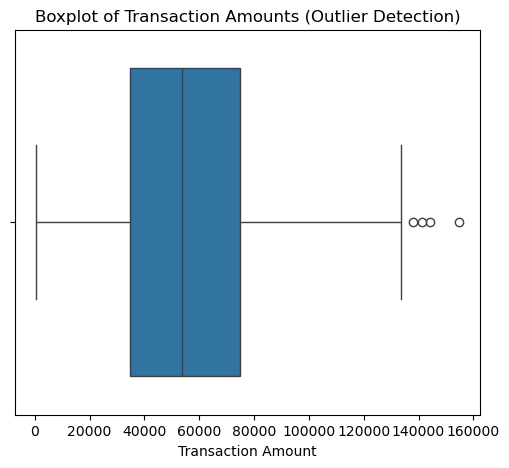

In [37]:
import seaborn as sns
plt.figure(figsize=(6,5))
sns.boxplot(x=ms_df["TransactionAmount"])
plt.title("Boxplot of Transaction Amounts (Outlier Detection)")
plt.xlabel("Transaction Amount")
plt.show()

* Distribution of activity levels

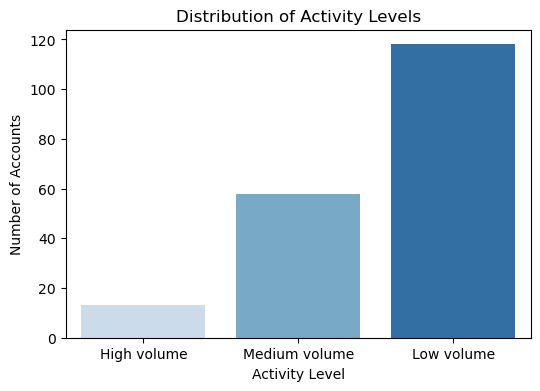

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=account_txn_count, x="Activity_Level", palette="Blues", hue="Activity_Level")
plt.title("Distribution of Activity Levels")
plt.xlabel("Activity Level")
plt.ylabel("Number of Accounts")
plt.show()

* Distribution of Transaction types

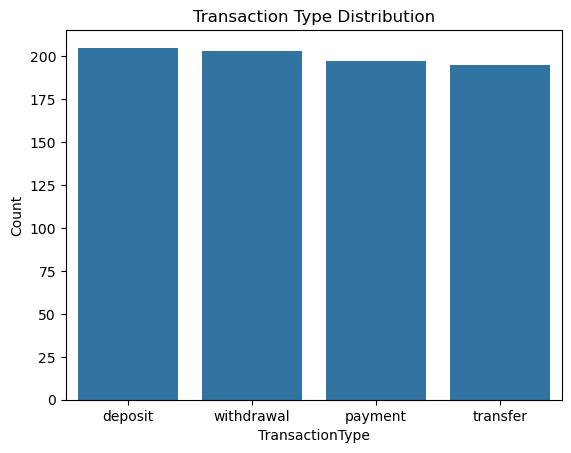

In [39]:
txn_type = ms_df['TransactionType'].value_counts()

sns.barplot(x=txn_type.index, y=txn_type.values)
plt.title("Transaction Type Distribution")
plt.ylabel("Count")
plt.show()

* Account Balance Distribution

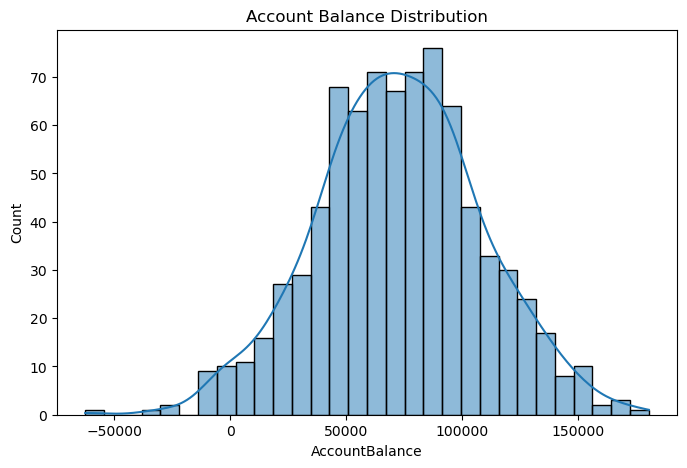

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(ms_df['AccountBalance'], bins=30, kde=True)
plt.title("Account Balance Distribution")
plt.show()

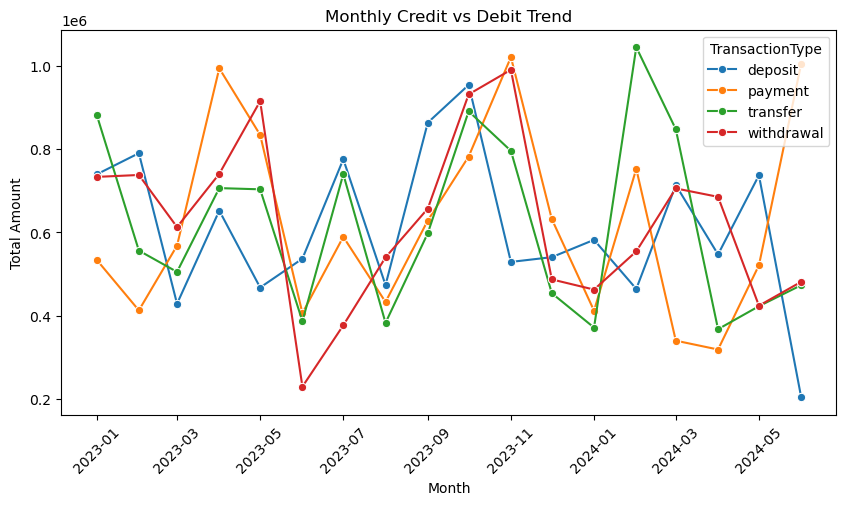

In [44]:
ms_df["Month"] = pd.to_datetime(ms_df["TransactionDate"]).dt.to_period("M").dt.to_timestamp()

monthly = ms_df.groupby(["Month", "TransactionType"])["TransactionAmount"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x="Month", y="TransactionAmount", hue="TransactionType", marker="o")
plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

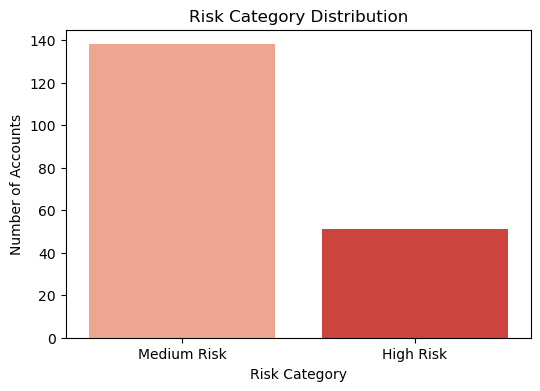

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(data=risk_flags, x="FinalRiskCategory", palette="Reds", hue="FinalRiskCategory")
plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Accounts")
plt.show()

### Task 6: Hypothesis Testing

Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts

In [22]:
# -------------------------------
# Do high-volume accounts maintain higher average balances?
# -------------------------------

from scipy.stats import ttest_ind

# Merge activity count and average balance into one table
analysis_df = pd.merge(account_txn_count, avg_balance, on='AccountID')

In [34]:
high_balances = analysis_df[analysis_df['Activity_Level'] == 'High volume']['AccountBalance']
low_balances = analysis_df[analysis_df['Activity_Level'] == 'Low volume']['AccountBalance']

# Define Hypothesis
# H₀ (Null Hypothesis): High-volume accounts do not have higher average balances
# H₁ (Alternative Hypothesis): High-volume accounts do have higher average balances

# Perform one-tailed t-test
t_stat, p_value = ttest_ind(high_balances, low_balances, alternative='greater')

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nConclusion: Reject H₀") 
    print("High-volume accounts have significantly higher average balances.\n")
else:
    print("\nConclusion: Fail to Reject H₀")
    print("No statistical evidence that high-volume accounts maintain higher balances.\n")

T-statistic: 0.6789784847828001
P-value: 0.24918393206756767

Conclusion: Fail to Reject H₀
No statistical evidence that high-volume accounts maintain higher balances.



##### Hypothesis Testing Insights :
* The hypothesis test indicates that high-volume transaction accounts do not have significantly higher average balances compared to low-volume accounts.
* This indicates whether customer activity influences balance behavior.
* Transaction frequency alone is not a reliable predictor of customer bank balance.



#### Project Insights

* When categorizing accounts into High / Medium / Low activity, Majority may fall into low or medium segments.High activity segment is usually a minority but operationally important.
* Standard deviation / coefficient of variation analysis showed Some accounts have highly unstable balances.Others maintain consistent balance levels.
* From gap analysis (>60 days inactivity),Several accounts show dormancy patterns.Some accounts reactivate after long inactivity gaps.Dormancy does not always mean churn — some customers are seasonal or event-driven users.
* Hypothesis testing showed that Customer engagement (transactions) and customer financial strength (balance) are independent dimensions.
  